In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# LOAD + CLEAN (same pipeline as ANN script)

In [6]:
df = pd.read_csv('IndianFlightdata - Sheet1.csv')
df.dropna(inplace=True)

df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df['Journey_Day']     = df['Date_of_Journey'].dt.day
df['Journey_Month']   = df['Date_of_Journey'].dt.month
df['Dep_Hour']        = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Dep_Minute']      = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute
df['Arrival_Time_Clean'] = df['Arrival_Time'].str.extract(r'(\d{1,2}:\d{2})')[0]
df['Arr_Hour']        = pd.to_datetime(df['Arrival_Time_Clean'], format='%H:%M').dt.hour
df['Arr_Minute']      = pd.to_datetime(df['Arrival_Time_Clean'], format='%H:%M').dt.minute

def parse_duration(dur):
    h, m = 0, 0
    if 'h' in dur:
        h = int(dur.split('h')[0].strip())
        rest = dur.split('h')[1].strip()
        if 'm' in rest:
            m = int(rest.replace('m','').strip())
    elif 'm' in dur:
        m = int(dur.replace('m','').strip())
    return h * 60 + m

df['Duration_mins'] = df['Duration'].apply(parse_duration)
stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Stops'] = df['Total_Stops'].map(stops_map)

le = LabelEncoder()
for col in ['Airline', 'Source', 'Destination', 'Additional_Info']:
    df[col + '_Enc'] = le.fit_transform(df[col])

feature_cols = [
    'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute',
    'Arr_Hour', 'Arr_Minute', 'Duration_mins', 'Stops',
    'Airline_Enc', 'Source_Enc', 'Destination_Enc', 'Additional_Info_Enc'
]

X = df[feature_cols].values
y = df['Price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Data ready. Training models...\n")

Data ready. Training models...



# DEFINE MODELS

In [9]:
models = {
    'ANN\n(128→64→32)': MLPRegressor(
        hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
        learning_rate_init=0.001, max_iter=500, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, random_state=42),
    'KNN\n(k=10)': KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'SVR\n(Linear)': SVR(kernel='linear', C=10),
    'Linear\nRegression': LinearRegression(),
#     'Ridge\n(α=1)': Ridge(alpha=1.0),
#     'Ridge\n(α=10)': Ridge(alpha=10.0),
#     'Lasso\n(α=1)': Lasso(alpha=1.0),
#     'Lasso\n(α=10)': Lasso(alpha=10.0),
}

# TRAIN & EVALUATE

In [12]:
results = []

for name, model in models.items():
    print(f"Training {name.replace(chr(10),' ')}...")
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results.append({
        'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'MAPE': mape, 'y_pred': y_pred
    })
    print(f"  R²={r2:.4f}  MAE=₹{mae:,.0f}  RMSE=₹{rmse:,.0f}  MAPE={mape:.1f}%")

Training ANN (128→64→32)...
  R²=0.8395  MAE=₹1,181  RMSE=₹1,860  MAPE=14.4%
Training KNN (k=10)...
  R²=0.8105  MAE=₹1,161  RMSE=₹2,021  MAPE=13.7%
Training SVR (Linear)...
  R²=0.3827  MAE=₹2,386  RMSE=₹3,648  MAPE=26.6%
Training Linear Regression...
  R²=0.4380  MAE=₹2,448  RMSE=₹3,481  MAPE=31.1%


In [14]:
results.sort(key=lambda x: x['R2'], reverse=True)
model_names = [r['Model'] for r in results]
r2_vals     = [r['R2']   for r in results]
mae_vals    = [r['MAE']  for r in results]
rmse_vals   = [r['RMSE'] for r in results]
mape_vals   = [r['MAPE'] for r in results]

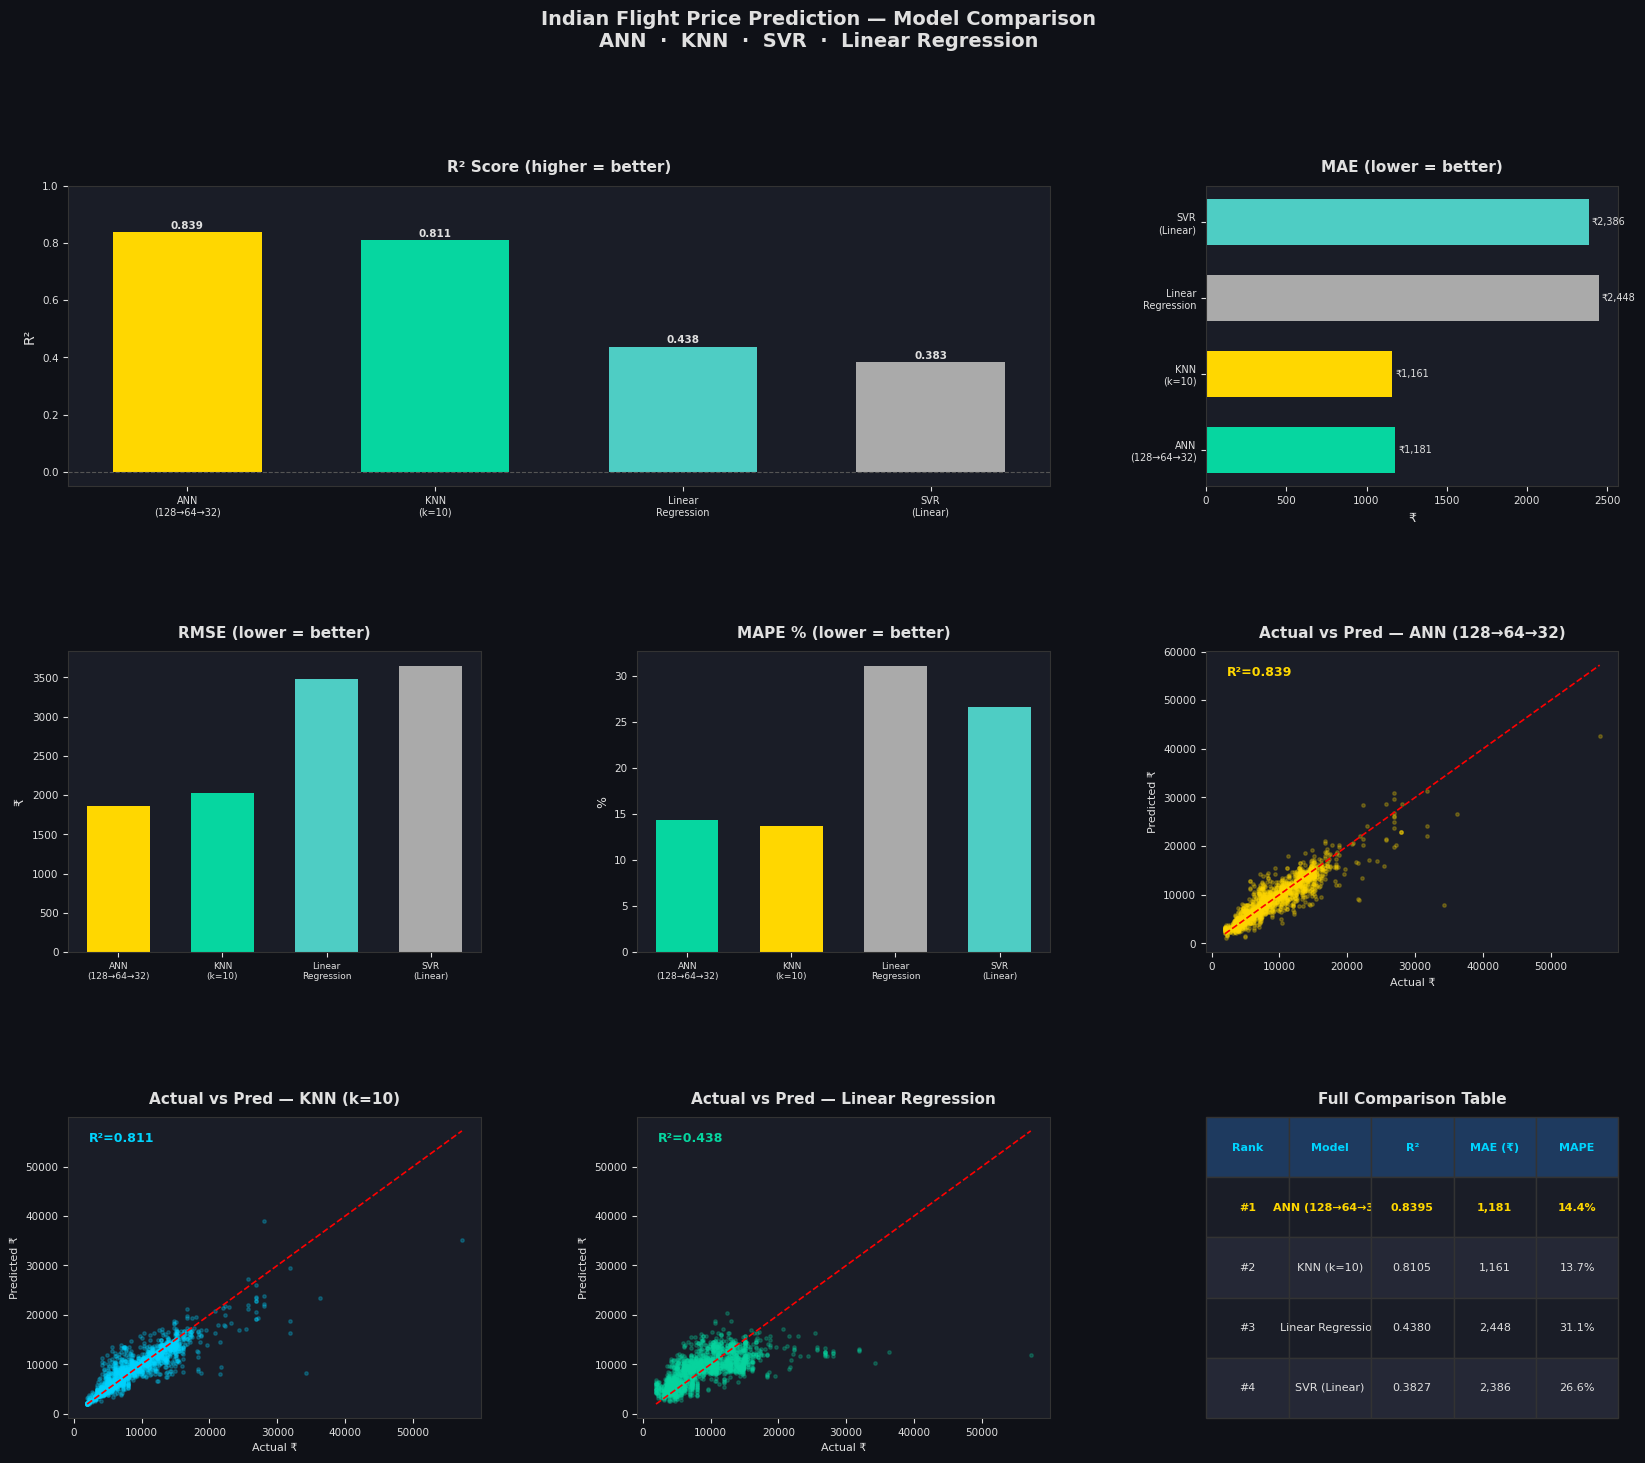

In [32]:
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

BEST   = '#ffd700'
GOOD   = '#00d4ff'
MID    = '#06d6a0'
WEAK   = '#888'
TEXT   = '#e0e0e0'
PANEL  = '#1a1d27'
RED    = '#ff6b6b'

def get_color(val, vals, reverse=False):
    """Gold for best, gradient otherwise"""
    best_fn = max if not reverse else min
    if val == best_fn(vals):
        return BEST
    rank = sorted(vals, reverse=not reverse).index(val)
    palette = [GOOD, MID, '#4ecdc4', '#aaa', WEAK, WEAK, WEAK, WEAK, WEAK, WEAK]
    return palette[min(rank, len(palette)-1)]

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors=TEXT, labelsize=7.5)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

# ── R² Bar Chart ──────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
style_ax(ax0, 'R² Score (higher = better)')
colors_r2 = [get_color(v, r2_vals) for v in r2_vals]
bars = ax0.bar(model_names, r2_vals, color=colors_r2, width=0.6)
ax0.set_ylabel('R²', color=TEXT, fontsize=10)
ax0.set_ylim(min(0, min(r2_vals)) - 0.05, 1.0)
ax0.axhline(0, color='#555', lw=0.8, linestyle='--')
for bar, val in zip(bars, r2_vals):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=7.5,
             color=TEXT, fontweight='bold')
ax0.tick_params(axis='x', labelsize=7)

# ── MAE Bar Chart ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
style_ax(ax1, 'MAE (lower = better)')
colors_mae = [get_color(v, mae_vals, reverse=True) for v in mae_vals]
ax1.barh(model_names, mae_vals, color=colors_mae, height=0.6)
ax1.set_xlabel('₹', color=TEXT, fontsize=9)
ax1.tick_params(axis='y', labelsize=7)
for i, v in enumerate(mae_vals):
    ax1.text(v + 20, i, f'₹{v:,.0f}', va='center', fontsize=7, color=TEXT)

# ── RMSE Bar Chart ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, 'RMSE (lower = better)')
colors_rmse = [get_color(v, rmse_vals, reverse=True) for v in rmse_vals]
ax2.bar(model_names, rmse_vals, color=colors_rmse, width=0.6)
ax2.set_ylabel('₹', color=TEXT, fontsize=9)
ax2.tick_params(axis='x', labelsize=6.5)

# ── MAPE Bar Chart ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, 'MAPE % (lower = better)')
colors_mape = [get_color(v, mape_vals, reverse=True) for v in mape_vals]
ax3.bar(model_names, mape_vals, color=colors_mape, width=0.6)
ax3.set_ylabel('%', color=TEXT, fontsize=9)
ax3.tick_params(axis='x', labelsize=6.5)

# ── Actual vs Predicted: top 3 models ─────────────
top3 = results[:3]
axes_pred = [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]
colors_scatter = [BEST, GOOD, MID]
for ax, res, col in zip(axes_pred, top3, colors_scatter):
    clean = res['Model'].replace('\n', ' ')
    style_ax(ax, f'Actual vs Pred — {clean}')
    ax.scatter(y_test, res['y_pred'], alpha=0.25, s=6, color=col)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2)
    ax.set_xlabel('Actual ₹', color=TEXT, fontsize=8)
    ax.set_ylabel('Predicted ₹', color=TEXT, fontsize=8)
    ax.text(0.05, 0.92, f'R²={res["R2"]:.3f}', transform=ax.transAxes,
            color=col, fontsize=9, fontweight='bold')

# ── Summary Table ─────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
ax5.set_facecolor(PANEL)
ax5.axis('off')
ax5.set_title('Full Comparison Table', color=TEXT, fontsize=11, fontweight='bold', pad=10)

rows = [['Rank', 'Model', 'R²', 'MAE (₹)', 'MAPE']]
for i, r in enumerate(results, 1):
    rows.append([
        f'#{i}',
        r['Model'].replace('\n', ' '),
        f'{r["R2"]:.4f}',
        f'{r["MAE"]:,.0f}',
        f'{r["MAPE"]:.1f}%'
    ])

table = ax5.table(cellText=rows[1:], colLabels=rows[0],
                  cellLoc='center', loc='center',
                  bbox=[0.0, 0.0, 1.0, 1.0])
table.auto_set_font_size(False)
table.set_fontsize(8)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#252836' if r % 2 == 0 else PANEL)
    cell.set_text_props(color=TEXT)
    cell.set_edgecolor('#333')
    if r == 0:
        cell.set_facecolor('#1e3a5f')
        cell.set_text_props(color=GOOD, fontweight='bold')
    if r == 1:  # best model
        cell.set_text_props(color=BEST, fontweight='bold')

fig.suptitle('Indian Flight Price Prediction — Model Comparison\n'
             'ANN  ·  KNN  ·  SVR  ·  Linear Regression',
             color=TEXT, fontsize=14, fontweight='bold', y=0.99)

plt.show()